In [1]:
%cd ../../..

/path/to/repo/my-coles-gnn-experimetns/scenario_age_pred


/path/to/repo/.local/lib/python3.10/site-packages/IPython/core/magics/osm.py:417: UserWarning: This is now an optional IPython functionality, setting dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


In [2]:
from collections import defaultdict
import os

BATCH_SIZE = 40
MAX_EPOCHES_OPTIONS = range(10, 160, 10) 
SPLIT_COUNT = 2

LOSS_ALPHA_OPTIONS=[0, 0.01, 0.5, 0.85, 0.15]
N_TRIPLETS_PER_ANCHOR_USER_OPTIONS=[1, 32, 128]
MIN_ELEMENTS_IN_BIN_WHEN_ONE_BIN_ONLY = 5


expected_experiments = []

for loss_alpha in LOSS_ALPHA_OPTIONS:
    for n_triplets_per_anchor_user in N_TRIPLETS_PER_ANCHOR_USER_OPTIONS:
        for train_epochs in MAX_EPOCHES_OPTIONS:
            experiment_name=f"coles_bpr__batch_size_{BATCH_SIZE}__split_count_{SPLIT_COUNT}__loss_alpha_{loss_alpha}__triplets_per_user_{n_triplets_per_anchor_user}__bin_separation_margin_{MIN_ELEMENTS_IN_BIN_WHEN_ONE_BIN_ONLY}__epoches_{train_epochs}__try_2"
            expected_experiments.append(experiment_name)


In [3]:
len(expected_experiments)

225

In [4]:
expected_experiments[:10]

['coles_bpr__loss_alpha_0__triplets_per_user_1__bin_separation_margin_5__epoches_10__try_2',
 'coles_bpr__loss_alpha_0__triplets_per_user_1__bin_separation_margin_5__epoches_20__try_2',
 'coles_bpr__loss_alpha_0__triplets_per_user_1__bin_separation_margin_5__epoches_30__try_2',
 'coles_bpr__loss_alpha_0__triplets_per_user_1__bin_separation_margin_5__epoches_40__try_2',
 'coles_bpr__loss_alpha_0__triplets_per_user_1__bin_separation_margin_5__epoches_50__try_2',
 'coles_bpr__loss_alpha_0__triplets_per_user_1__bin_separation_margin_5__epoches_60__try_2',
 'coles_bpr__loss_alpha_0__triplets_per_user_1__bin_separation_margin_5__epoches_70__try_2',
 'coles_bpr__loss_alpha_0__triplets_per_user_1__bin_separation_margin_5__epoches_80__try_2',
 'coles_bpr__loss_alpha_0__triplets_per_user_1__bin_separation_margin_5__epoches_90__try_2',
 'coles_bpr__loss_alpha_0__triplets_per_user_1__bin_separation_margin_5__epoches_100__try_2']

In [5]:
HYDRA_OUTPUTS_PATH ='hydra_outputs/MERGED_SUPERCOMPUTER_AND_S_COMPUTER_HYDRA'

In [6]:
all_hydra_outputs = os.listdir(HYDRA_OUTPUTS_PATH)

MAX_EPOCHS = 150

for loss_alpha in LOSS_ALPHA_OPTIONS:
    for n_triplets_per_anchor_user in N_TRIPLETS_PER_ANCHOR_USER_OPTIONS:
        full_experiment_name=f"coles_bpr__loss_alpha_{loss_alpha}__triplets_per_user_{n_triplets_per_anchor_user}__bin_separation_margin_{MIN_ELEMENTS_IN_BIN_WHEN_ONE_BIN_ONLY}__epoches_{MAX_EPOCHS}__try_2"
        assert full_experiment_name in all_hydra_outputs

In [7]:
import sys, os; sys.path.append(os.path.abspath( '..'))

In [8]:
from omegaconf import OmegaConf 

In [9]:
import sys
import os

sys.path.append(os.path.dirname(os.getcwd()))

In [10]:
from ptls_extension_2024_research.latex_table_creation.latex_table_creation import create_latex_table, get_metrics
from ptls_extension_2024_research.latex_table_creation.experiment_dicts_list_modifiers import bolden_top_k, sort_by_col
from ptls_extension_2024_research.latex_table_creation.prefix_map import get_idxs_where_all_metrics_superpass, prefix_map_from_idx_lst

/path/to/repo/.local/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [11]:
with open("results/scenario_age_bpr__supercomputer.txt") as f:
    report_file_content = f.read()

In [12]:
from typing import Optional
import re


from ptls_extension_2024_research.latex_table_creation.hyperparam_getters import get_batchsize_from_config, get_split_count_from_config


# Some information is present in name only, everything else is 
# suposed to be retrived from the config (yaml read wit OmegaConf).
# For a uniformal interface both config and experiment_name are always passed to hyperparam getters.





# def get_gnn_loss_alpha(config, experiment_name) -> Optional[float]:
#     matches = re.search(r'wl-(\d+\.\d+)', experiment_name)
#     if matches is None:
#         return None
#     return float(matches.group(1))


# def get_gnn_task(config, experiment_name) -> str:
#     if 'GRACE' in experiment_name:
#         return 'GRACE'
#     return 'Link and weight prediction'


# def get_has_residual(config, experiment_name) -> str:
#     has_residual_str = re.search(r'residual-(true|True|False)', experiment_name).group(1)
#     if  has_residual_str in ['true', 'True']:
#         return True
#     return False

# def get_weight_decay(config, experiment_name):
#     return re.search(r'weight_decay-(\d*\.?\d+)', experiment_name).group(1)

def get_convex_loss_alpha_from_config(config, experiment_name) -> float:
    return config['pl_module']['loss']['alpha']

def get_triplets_per_user_from_config(config, experiment_name) -> int:
    return config['pl_module']['loss']['loss2']['triplet_selector']['num_triplets_per_anchor_user']


def get_min_users_in_separated_single_bin_from_config(config, experiment_name) -> int:
    return config['pl_module']['loss']['loss2']['triplet_selector']['bin_separation_strategy']['min_elements_in_bin']



def get_train_epoches(config, experiment_name) -> int:
    # Look for 'epoches_<number>' but exclude 'pretrain_epoches_<number>'
    matches = re.search(r'epoches_(\d+)', experiment_name)
    return int(matches.group(1))





In [13]:

hyperparams_to_getters = {
    r"\textbf{Triplets per user}": get_triplets_per_user_from_config,
    r"\textbf{Loss alpha}": get_convex_loss_alpha_from_config,
    r"\textbf{Min users in separated single bin}": get_convex_loss_alpha_from_config,
    r"\textbf{Batch size}": get_batchsize_from_config,
    r"\textbf{Split count}": get_split_count_from_config,
    r"\textbf{Train epoches}": get_train_epoches,

}

In [14]:
experiment_dicts_list = []

for experiment_name in expected_experiments:
    hydra_config_path = os.path.join(HYDRA_OUTPUTS_PATH, experiment_name, '.hydra', 'config.yaml')
    hydra_config_path = re.sub(r'epoches_(\d+)', 'epoches_150', hydra_config_path)
    config = OmegaConf.load(hydra_config_path)
    hyperparams = {k: v(config, experiment_name) for k, v in hyperparams_to_getters.items()}
    metrics = get_metrics(report_file_content, experiment_name, {'accuracy': r"\textbf{ACC test}"})
    if metrics is not None:
        experiment_dicts_list.append({**hyperparams, **metrics})

Could not find experiment coles_bpr__loss_alpha_0__triplets_per_user_1__bin_separation_margin_5__epoches_100__try_2 in file content
Could not find experiment coles_bpr__loss_alpha_0__triplets_per_user_1__bin_separation_margin_5__epoches_110__try_2 in file content
Could not find experiment coles_bpr__loss_alpha_0__triplets_per_user_1__bin_separation_margin_5__epoches_120__try_2 in file content
Could not find experiment coles_bpr__loss_alpha_0__triplets_per_user_1__bin_separation_margin_5__epoches_130__try_2 in file content
Could not find experiment coles_bpr__loss_alpha_0__triplets_per_user_1__bin_separation_margin_5__epoches_140__try_2 in file content
Could not find experiment coles_bpr__loss_alpha_0__triplets_per_user_1__bin_separation_margin_5__epoches_150__try_2 in file content
Could not find experiment coles_bpr__loss_alpha_0__triplets_per_user_32__bin_separation_margin_5__epoches_10__try_2 in file content
Could not find experiment coles_bpr__loss_alpha_0__triplets_per_user_32__bin

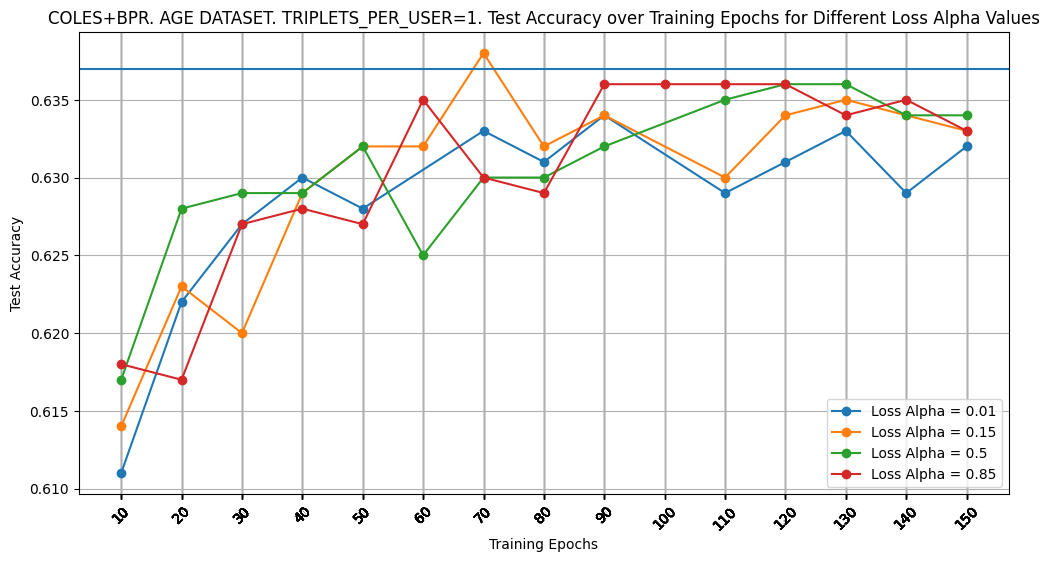

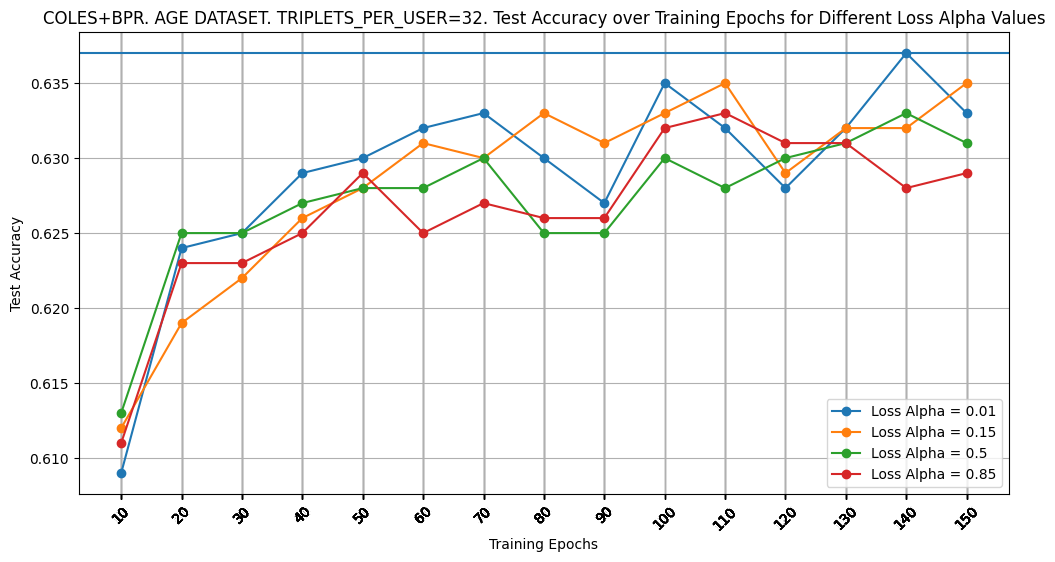

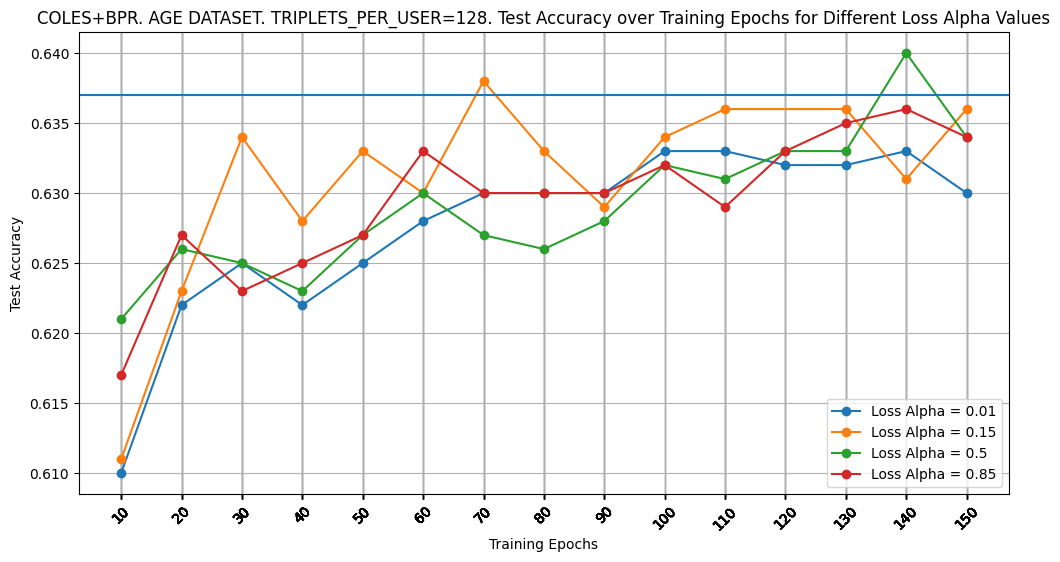

In [15]:
import pandas as pd
import matplotlib.pyplot as plt

GENDER_BASELINE_ACC = 0.637


df = pd.DataFrame(experiment_dicts_list)

for triplets_per_user in [1, 32, 128]:
    plt.figure(figsize=(12, 6))

    for alpha in [0.01, 0.15, 0.5, 0.85]:
        sub_df = df[(df[r'\textbf{Triplets per user}'] == triplets_per_user) & (df['\\textbf{Loss alpha}'] == alpha)]
        plt.plot(sub_df['\\textbf{Train epoches}'], sub_df['\\textbf{ACC test}'], label=f'Loss Alpha = {alpha}', marker='o')

    plt.axhline(GENDER_BASELINE_ACC)

    plt.title(f'COLES+BPR. AGE DATASET. TRIPLETS_PER_USER={triplets_per_user}. Test Accuracy over Training Epochs for Different Loss Alpha Values')
    plt.xlabel('Training Epochs')
    plt.ylabel('Test Accuracy')
    plt.legend()
    plt.grid(True)
    plt.xticks(df['\\textbf{Train epoches}'], rotation=45)
    plt.show()


In [16]:
WEIGHTS_TYPE = 'type 2'

# experiment_dicts_list stores raw values

# experiment_dicts_list stores raw values, list is sorted
experiment_dicts_list = sort_by_col(experiment_dicts_list, r"\textbf{ACC test}")
# prefix_map = prefix_map_from_idx_lst(get_idxs_where_all_metrics_superpass(experiment_dicts_list, COLES_METRICS), "\n\\rowcolor{gray!50}\n")

# experiment_dicts_list stores strings
experiment_dicts_of_str_list = bolden_top_k(experiment_dicts_list, 3, [r"\textbf{ACC test}"])




EXPERIMENT_NAME = r'\makecell{Coles only with bpr}'

experiment_data = {
    EXPERIMENT_NAME: {
        WEIGHTS_TYPE: experiment_dicts_of_str_list
    }
}



In [17]:
hyperparameters = hyperparameter_header_strs = list(experiment_dicts_list[0].keys())

caption = "Coles bpr. Scenario age"

row_prefix_dict = None

# row_prefix_dict = {
#     EXPERIMENT_NAME: {
#         WEIGHTS_TYPE: prefix_map
#     }
# }

latex_table = create_latex_table(experiment_data, hyperparameters, hyperparameter_header_strs, caption, row_prefix_dict)

print(latex_table)

\begin{table*}[h!]
\centering
\resizebox{\textwidth}{!}{%
\begin{tabular}{|c|c|c|c|c|c|c|c|c|}
\hline
\textbf{Model} & \textbf{Type of weights} & \textbf{Triplets per user} & \textbf{Loss alpha} & \textbf{Min users in separated single bin} & \textbf{Batch size} & \textbf{Split count} & \textbf{Train epoches} & \textbf{ACC test}\\
\hline
\multirow{184}{*}{\makecell{Coles only with bpr}} &\multirow{184}{*}{type 2} & 128 & 0.5 & 0.5 & 64 & 2 & 140 & \textbf{0.64} \\ \cline{3-9} 
& &1 & 0.15 & 0.15 & 64 & 2 & 70 & \textbf{0.638} \\ \cline{3-9} 
& &128 & 0.15 & 0.15 & 64 & 2 & 70 & \textbf{0.638} \\ \cline{3-9} 
& &32 & 0.01 & 0.01 & 64 & 2 & 140 & 0.637 \\ \cline{3-9} 
& &1 & 0.5 & 0.5 & 64 & 2 & 120 & 0.636 \\ \cline{3-9} 
& &1 & 0.5 & 0.5 & 64 & 2 & 130 & 0.636 \\ \cline{3-9} 
& &1 & 0.85 & 0.85 & 64 & 2 & 90 & 0.636 \\ \cline{3-9} 
& &1 & 0.85 & 0.85 & 64 & 2 & 100 & 0.636 \\ \cline{3-9} 
& &1 & 0.85 & 0.85 & 64 & 2 & 110 & 0.636 \\ \cline{3-9} 
& &1 & 0.85 & 0.85 & 64 & 2 & 120 & 0.636